In [3]:
import sklearn
print(sklearn.__version__)

1.9.0


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [9]:
df = pd.read_csv("ifood_df.csv", sep="\t")

df.head()

,"Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall"
0,"58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7..."
1,"46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,..."
2,"71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4..."
3,"26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,..."
4,"58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0..."


In [10]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     Non-Null Count  Dtype
---  ------                                                                                                                                                                                                                                                                                                                                        

,"Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall"
count,2205
unique,2021
top,"63841.0,0,1,64,635,15,100,20,7,131,1,9,3,9,6,0..."
freq,3


In [11]:
df.isnull().sum()

Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall    0
dtype: int64

In [12]:
df.dropna(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(184)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

In [19]:
print(df.columns.tolist())

['Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall']


In [20]:
import pandas as pd

df = pd.read_csv("ifood_df.csv", sep=",")

In [21]:
print(df.shape)
print(df.columns.tolist())

(2205, 39)
['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married', 'marital_Single', 'marital_Together', 'marital_Widow', 'education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds', 'AcceptedCmpOverall']


In [22]:
features = df[[
    'Income',
    'Age',
    'MntTotal',
    'NumWebPurchases',
    'NumStorePurchases',
    'NumCatalogPurchases',
    'Customer_Days'
]]

In [23]:
features.head()

,Income,Age,MntTotal,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,Customer_Days
0,58138.0,63,1529,8,4,10,2822
1,46344.0,66,21,1,2,1,2272
2,71613.0,55,734,8,10,2,2471
3,26646.0,36,48,2,4,0,2298
4,58293.0,39,407,5,6,3,2320


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [25]:
scaled_features.shape

(2205, 7)

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

C:\Users\Sandhiya\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Sandhiya\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\Sandhiya\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Python314\Lib\subprocess.py", line 555, in run
    with Popen(*popenarg

In [27]:
print("Done")

Done


In [28]:
print(wcss)

[15435.0, 9093.641308229744, 7947.073249003262, 7163.268698229025, 6581.203902244651, 6100.65632982713, 5664.5323170281, 5355.755179769825, 5092.932613466224, 4875.268758949398]


In [29]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

print(wcss)

[15435.0, 9093.641308229744, 7947.073249003262, 7163.268698229025, 6581.203902244651, 6100.65632982713, 5664.532317028101, 5355.755179769825, 5092.932613466224, 4875.268758949398]


In [30]:
import warnings
warnings.filterwarnings("ignore")

In [31]:
print(wcss)

[15435.0, 9093.641308229744, 7947.073249003262, 7163.268698229025, 6581.203902244651, 6100.65632982713, 5664.532317028101, 5355.755179769825, 5092.932613466224, 4875.268758949398]


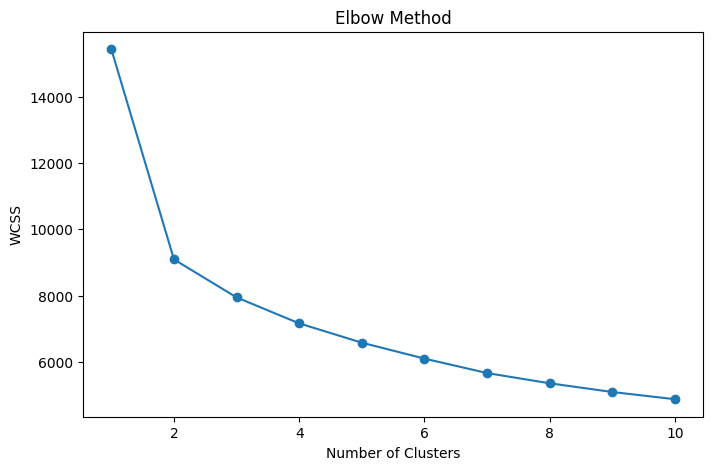

In [39]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.savefig(
    "Elbow Method.png"
)
plt.show()

In [33]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(scaled_features)

df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Cluster
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,1,0,0,1529,1441,0,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,1,0,0,21,15,0,1
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,0,0,1,0,0,734,692,0,3
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,0,0,1,0,0,48,43,0,1
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,1,407,392,0,3


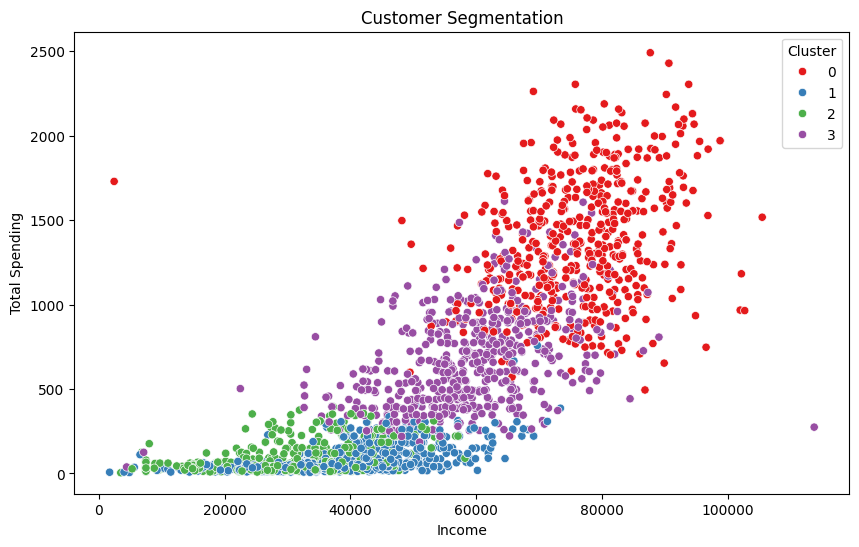

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Income',
    y='MntTotal',
    hue='Cluster',
    palette='Set1'
)

plt.title('Customer Segmentation')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.savefig(
    "Customer Segmentation.png"
)
plt.show()

In [35]:
cluster_summary = df.groupby('Cluster')[[
    'Income',
    'Age',
    'MntTotal',
    'NumWebPurchases',
    'NumStorePurchases',
    'NumCatalogPurchases'
]].mean()

cluster_summary

,Income,Age,MntTotal,NumWebPurchases,NumStorePurchases,NumCatalogPurchases
Cluster,,,,,,
0,76123.027523,50.889908,1367.691743,5.132110,8.667890,6.357798
1,38419.989437,50.566901,87.167254,2.058099,3.390845,0.593310
2,30430.993802,45.685950,90.592975,2.287190,3.167355,0.597107
3,58862.687500,56.080592,661.424342,6.527961,7.661184,2.865132


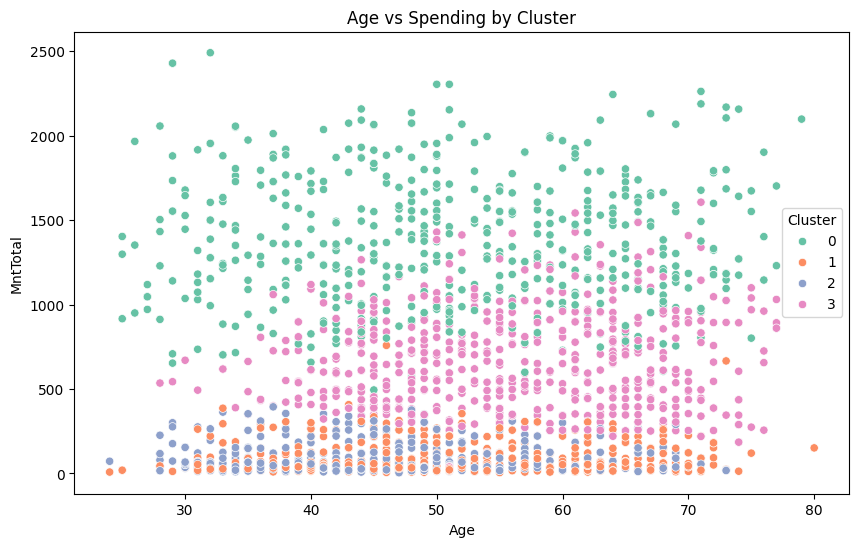

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Age',
    y='MntTotal',
    hue='Cluster',
    palette='Set2'
)

plt.title('Age vs Spending by Cluster')
plt.savefig(
    "Age vs Spending by Cluster.png"
)
plt.show()

In [40]:
cluster_summary = df.groupby('Cluster')[[
    'Income',
    'Age',
    'MntTotal',
    'NumWebPurchases',
    'NumStorePurchases',
    'NumCatalogPurchases'
]].mean()

print(cluster_summary)

               Income        Age     MntTotal  NumWebPurchases  \
Cluster                                                          
0        76123.027523  50.889908  1367.691743         5.132110   
1        38419.989437  50.566901    87.167254         2.058099   
2        30430.993802  45.685950    90.592975         2.287190   
3        58862.687500  56.080592   661.424342         6.527961   

         NumStorePurchases  NumCatalogPurchases  
Cluster                                          
0                 8.667890             6.357798  
1                 3.390845             0.593310  
2                 3.167355             0.597107  
3                 7.661184             2.865132  


In [41]:
print(df['Cluster'].value_counts())

Cluster
3    608
1    568
0    545
2    484
Name: count, dtype: int64


In [42]:
df.to_csv("customer_segmentation_cleaned.csv", index=False)

print("File saved successfully!")

File saved successfully!


In [43]:
saved_df = pd.read_csv("customer_segmentation_cleaned.csv")

saved_df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Cluster
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,1,0,0,1529,1441,0,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,1,0,0,21,15,0,1
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,0,0,1,0,0,734,692,0,3
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,0,0,1,0,0,48,43,0,1
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,1,407,392,0,3
